<a href="https://www.kaggle.com/code/kamillemcquillen/bellabeat-capstone-project?scriptVersionId=322125386" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Introduction

For this capstone project in the Google Data Analytics course, I was assigned a case study as a Jr. Data Analyst for Bellabeat. Bellabeat is a high-tech manufacturer of health-focused wearable devices, founded by Urška Sršen and Sando Mur. While Bellabeat has been a successful small business, the company has asked the analytics team to analyze how consumers use smart health-focused devices and, based on these insights, develop marketing strategies to drive sales growth for Bellabeat.
The method used in this course for strategizing when working with datasets is processed through the phases of "**Ask, Prepare, Process, Analyze, Share, and Act**." This framework will guide and structure the process of this project. The company's mission is to approach women's health through a holistic lens. Bellabeat's key products include:

Leaf, the company's first wearable, designed to track activity, sleep, stress, meditation, and reproductive health;
Time, a hybrid wellness watch that calculates a wellness score and monitors activity, sleep, menstrual cycle, meditation, and hydration;
Spring, a smart tracking water bottle;
IVY+, the newest generation device that calculates a wellness and readiness score, tracks skin temperature, monitors heart rate, cardiac coherence, respiratory rate, activity, and sleep, and correlates menstrual cycle data and lifestyle habits into biometric readings.

# Phase One: Ask
The Main Issue

Bellabeat aims to expand its presence in the global smart health device industry. While the company has been successful to date, it needs data-driven insights to better guide its marketing strategy. To support this goal, the analytics and marketing teams need to develop a clear understanding of how consumers use smart health devices that are not produced by Bellabeat. These insights will help inform product positioning and overall decision-making. Both stakeholders and the marketing team will benefit from this analysis, as having the big picture — supported by statistics and clear recommendations — will help all departments understand how Bellabeat can improve sales.

The main challenge is understanding how people use smart devices in their daily lives and identifying usage trends that can help drive sales growth. Insights from this analysis will help Bellabeat decide which product features to highlight, better compete with other smart device companies, and determine the best ways to reach new customers.

**Project Approach**
To address this challenge, we will analyze a Fitbit dataset that contains fitness-related data from wearable technology. After cleaning and analyzing the data, we will focus on a single Bellabeat product and provide marketing recommendations based on my findings. The main areas of focus will be activity, sleep, weight, and steps.

# Phase two: Prepare
For this project, I'll be dissecting my analysis with the Kaggle dataset "Fitbit Fitness Tracker Data", provided by Möbius. I downloaded the dataset and saved it to my local drive. The file consists of 29 .CSV files in total.
After unzipping the file, the first folder contains data from 03/12/16–04/11/16, and the second folder contains data from 04/12/16–05/12/16. Upon loading into Google Sheets, the data appears in long format — one specification per row with a low quantity of columns. Each participant has a unique ID.
To make sure our data is safe from copyright concerns, I checked the metadata and found that the licensing is under CC0: Public Domain, meaning the author has waived all rights under copyright law. It is legal to modify and use this data freely for this project. https://www.kaggle.com/datasets/arashnic/fitbit

Researching the metadata further, this data was collected through a distributed survey via Amazon Mechanical Turk from 03/12/16–05/12/16. Thirty FitBit users consented to the submission of personal data from their wearable tracker devices, which included minute-level output for physical activity, heart rate, and sleep monitoring. https://zenodo.org/records/53894#.X9oeh3Uzaao

My concerns regarding the integrity of the dataset are as follows: the data was collected by a third party and the collection methods are unknown; the dataset contains a sample size of only approximately thirty participants; gender is unknown, which can introduce bias since Bellabeat is a women-targeted business; and the dataset does not include location data, which can create bias between city and rural activity levels. The dataset is also 10 years old and technology has advanced drastically since then. However, I still believe this dataset will allow me to identify trends in areas where Bellabeat devices may be lacking, which could lead to further advanced technology and sales growth for Bellabeat.



# Phase three: Process

For this project, I'll be cleaning data using Google Sheets and RStudio. I'll be collecting data from the daily activities, daily and hourly steps, daily calories, daily intensities, sleep, and calories burned. I chose to omit the minute-based data since, for the recommendations I'm searching for, the minute-to-minute data is irrelevant.

# Phase four: Google Sheets - Process

After uploading the files mentioned above, my cleaning process included using COUNTUNIQUE to find how many participants were represented across the data, verifying that the dates matched the metadata, and searching for null and outlier values using filters. I standardized the data by changing the dates to MM/DD/YY format, rounding numbers to whole values, and fixing time formatting to be consistent. I removed rows with zero values and unnecessary timestamps. I created pivot tables to easily display relationships within the cleaned data. I validated that the daily minutes did not exceed 1,440 (24 hours), that the data maintained chronological order, and that no values broke real-world rules.

For the first daily activity sheet I analyzed, I looked at the averages of total steps and total distance across light, moderate, very active, and sedentary time — to compare activity levels across user groups and establish a baseline for recommendations — then created a pivot table to clearly display the totaled averages. (P1 = first period of survey collected, P2 = second period of survey collected)

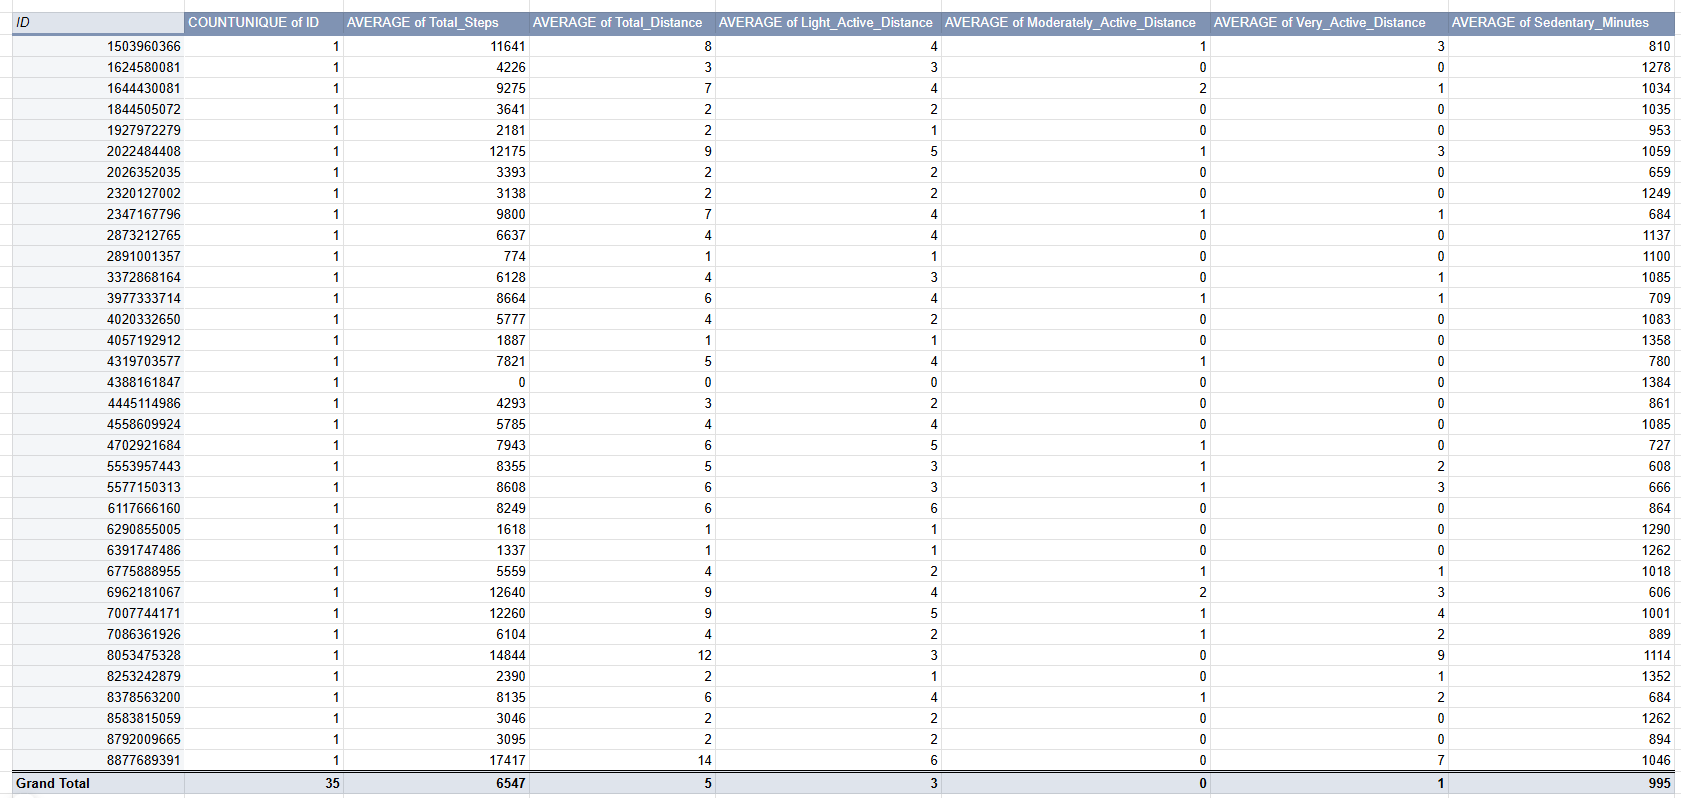

# Phase four: Process R Studio
I'm going to download the following packages to start our R analysis,

* tidyverse
* dblyr
* lubridate
* ggplot2
* janitor
* readr

In [1]:
# Step one load packages
library(tidyverse)
library(dplyr)
library(lubridate)
library(ggplot2)
library(janitor)
library(readr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘janitor’




The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test




Starting with importing the data sets and verifying what lives in each file.

In [2]:
# Verify files
list.files("../input/fitbit/mturkfitbit_export_3.12.16-4.11.16/")
list.files("../input/fitbit/mturkfitbit_export_4.12.16-5.12.16/")

[1] "Fitabase Data 3.12.16-4.11.16"

[1] "Fitabase Data 4.12.16-5.12.16"

These are all of the .CSV files that live in the dataset.

In [3]:
# Verifying more files
list.files("../input/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/")
list.files("../input/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/")

[1] "dailyActivity_merged.csv"           "heartrate_seconds_merged.csv"      
 [3] "hourlyCalories_merged.csv"          "hourlyIntensities_merged.csv"      
 [5] "hourlySteps_merged.csv"             "minuteCaloriesNarrow_merged.csv"   
 [7] "minuteIntensitiesNarrow_merged.csv" "minuteMETsNarrow_merged.csv"       
 [9] "minuteSleep_merged.csv"             "minuteStepsNarrow_merged.csv"      
[11] "weightLogInfo_merged.csv"

[1] "dailyActivity_merged.csv"           "dailyCalories_merged.csv"          
 [3] "dailyIntensities_merged.csv"        "dailySteps_merged.csv"             
 [5] "heartrate_seconds_merged.csv"       "hourlyCalories_merged.csv"         
 [7] "hourlyIntensities_merged.csv"       "hourlySteps_merged.csv"            
 [9] "minuteCaloriesNarrow_merged.csv"    "minuteCaloriesWide_merged.csv"     
[11] "minuteIntensitiesNarrow_merged.csv" "minuteIntensitiesWide_merged.csv"  
[13] "minuteMETsNarrow_merged.csv"        "minuteSleep_merged.csv"            
[15] "minuteStepsNarrow_merged.csv"       "minuteStepsWide_merged.csv"        
[17] "sleepDay_merged.csv"                "weightLogInfo_merged.csv"

**Now combining both periods from March to May into one dataset.**

In [4]:
# Combine datasets

# Daily Activity
daily_activity_1 <- read_csv("../input/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/dailyActivity_merged.csv")
daily_activity_2 <- read_csv("../input/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/dailyActivity_merged.csv")
daily_activity <- bind_rows(daily_activity_1, daily_activity_2)

# Hourly Steps
hourly_steps_1 <- read_csv("../input/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/hourlySteps_merged.csv")
hourly_steps_2 <- read_csv("../input/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/hourlySteps_merged.csv")
hourly_steps <- bind_rows(hourly_steps_1, hourly_steps_2)

# Weight Info
weight_info_1 <- read_csv("../input/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/weightLogInfo_merged.csv")
weight_info_2 <- read_csv("../input/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/weightLogInfo_merged.csv")
weight_info <- bind_rows(weight_info_1, weight_info_2)

# Sleep Day
sleep_day <- read_csv("../input/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/sleepDay_merged.csv")

Rows: 457 Columns: 15


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): ActivityDate
dbl (14): Id, TotalSteps, TotalDistance, TrackerDistance, LoggedActivitiesDi...



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 940 Columns: 15


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): ActivityDate
dbl (14): Id, TotalSteps, TotalDistance, TrackerDistance, LoggedActivitiesDi...


...

── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): Date
dbl (6): Id, WeightKg, WeightPounds, Fat, BMI, LogId
lgl (1): IsManualReport



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 413 Columns: 5


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): SleepDay
dbl (4): Id, TotalSleepRecords, TotalMinutesAsleep, TotalTimeInBed



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


**Now, with datasets combined, clean up column names and standardize dates.**

In [5]:
# Clean column names for all datasets
daily_activity <- daily_activity %>% clean_names()
hourly_steps <- hourly_steps %>% clean_names()
weight_info <- weight_info %>% clean_names()
sleep_day <- sleep_day %>% clean_names()

In [6]:
# Clean dates and times
daily_activity <- daily_activity %>%
  mutate(activity_date = as.Date(activity_date, format = "%m/%d/%Y"))

hourly_steps <- hourly_steps %>%
  mutate(activity_hour = as.POSIXct(activity_hour, format = "%m/%d/%Y %I:%M:%S %p"))

weight_info <- weight_info %>%
  mutate(date = as.POSIXct(date, format = "%m/%d/%Y %I:%M:%S %p"))

sleep_day <- sleep_day %>%
  mutate(sleep_day = as.POSIXct(sleep_day, format = "%m/%d/%Y %I:%M:%S %p"))


**Count unique the amount of users per data frame. Although sleep and weight fall below the sample size of 30, for practice I am keeping them included for practice.**

In [7]:
# Verify amount of people in each period
period1_users <- daily_activity %>%
  filter(activity_date >= as.Date("2016-03-12") & activity_date <= as.Date("2016-04-11")) %>%
  distinct(id) %>%
  nrow()

period2_users <- daily_activity %>%
  filter(activity_date >= as.Date("2016-04-12") & activity_date <= as.Date("2016-05-12")) %>%
  distinct(id) %>%
  nrow()

total_users <- daily_activity %>%
  distinct(id) %>%
  nrow()

cat("========== USERS PER PERIOD ==========\n")
cat("Period 1 (March 12 - April 11):", period1_users, "users\n")
cat("Period 2 (April 12 - May 12):", period2_users, "users\n")
cat("Total unique users:", total_users, "users\n")

========== USERS PER PERIOD ==========


Period 1 (March 12 - April 11): 35 users


Period 2 (April 12 - May 12): 33 users


Total unique users: 35 users


In [8]:
# Verify date range

cat("========== DATE RANGE ==========\n")
cat("First date:", format(min(daily_activity$activity_date), "%B %d, %Y"), "\n")
cat("Last date:", format(max(daily_activity$activity_date), "%B %d, %Y"), "\n")
cat("Total days span:", as.numeric(max(daily_activity$activity_date) - min(daily_activity$activity_date)) + 1, "days\n")
cat("Total weeks:", 9, "weeks\n")

========== DATE RANGE ==========


First date: March 12, 2016 


Last date: May 12, 2016 


Total days span: 62 days


Total weeks: 9 weeks


In [9]:
# Check for duplicates in each dataset
cat("Daily Activity duplicates:", sum(duplicated(daily_activity)), "\n")
cat("Hourly Steps duplicates:", sum(duplicated(hourly_steps)), "\n")
cat("Weight Info duplicates:", sum(duplicated(weight_info)), "\n")
cat("Sleep Day duplicates:", sum(duplicated(sleep_day)), "\n")

Daily Activity duplicates: 0 


Hourly Steps duplicates: 175 


Weight Info duplicates: 2 


Sleep Day duplicates: 3 


Here I found that there were 175 duplicates for hourly steps, which was a concerning outlier that didn't make sense. I can see that there is a gap in the timeline between the end of the first period and the start of the second period, which caused an overlap when the datasets were combined. I will also remove the duplicates found in the weight and sleep data.

In [10]:
# Remove duplicates
hourly_steps <- hourly_steps %>% distinct()
weight_info <- weight_info %>% distinct()
sleep_day <- sleep_day %>% distinct()

cat("Daily Activity duplicates:", sum(duplicated(daily_activity)), "\n")
cat("Hourly Steps duplicates:", sum(duplicated(hourly_steps)), "\n")
cat("Weight Info duplicates:", sum(duplicated(weight_info)), "\n")
cat("Sleep Day duplicates:", sum(duplicated(sleep_day)), "\n")


Daily Activity duplicates: 0 


Hourly Steps duplicates: 0 


Weight Info duplicates: 0 


Sleep Day duplicates: 0 


In [11]:
# Tibble at a glance
daily_activity %>% head(10)
hourly_steps %>% head(10)
weight_info %>% head(10)
sleep_day %>% head(10)

id,activity_date,total_steps,total_distance,tracker_distance,logged_activities_distance,very_active_distance,moderately_active_distance,light_active_distance,sedentary_active_distance,very_active_minutes,fairly_active_minutes,lightly_active_minutes,sedentary_minutes,calories
<dbl>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1503960366,2016-03-25,11004,7.11,7.11,0,2.57,0.46,4.07,0,33,12,205,804,1819
1503960366,2016-03-26,17609,11.55,11.55,0,6.92,0.73,3.91,0,89,17,274,588,2154
1503960366,2016-03-27,12736,8.53,8.53,0,4.66,0.16,3.71,0,56,5,268,605,1944
1503960366,2016-03-28,13231,8.93,8.93,0,3.19,0.79,4.95,0,39,20,224,1080,1932
1503960366,2016-03-29,12041,7.85,7.85,0,2.16,1.09,4.61,0,28,28,243,763,1886
1503960366,2016-03-30,10970,7.16,7.16,0,2.36,0.51,4.29,0,30,13,223,1174,1820
1503960366,2016-03-31,12256,7.86,7.86,0,2.29,0.49,5.04,0,33,12,239,820,1889
1503960366,2016-04-01,12262,7.87,7.87,0,3.32,0.83,3.64,0,47,21,200,866,1868
1503960366,2016-04-02,11248,7.25,7.25,0,3.00,0.45,3.74,0,40,11,244,636,1843


id,activity_hour,step_total
<dbl>,<dttm>,<dbl>
1503960366,2016-03-12 00:00:00,0
1503960366,2016-03-12 01:00:00,0
1503960366,2016-03-12 02:00:00,0
1503960366,2016-03-12 03:00:00,0
1503960366,2016-03-12 04:00:00,0
1503960366,2016-03-12 05:00:00,0
1503960366,2016-03-12 06:00:00,0
1503960366,2016-03-12 07:00:00,0
1503960366,2016-03-12 08:00:00,0


id,date,weight_kg,weight_pounds,fat,bmi,is_manual_report,log_id
<dbl>,<dttm>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>
1503960366,2016-04-05 23:59:59,53.3,117.5064,22,22.97,TRUE,1.459901e+12
1927972279,2016-04-10 18:33:26,129.6,285.7191,NA,46.17,FALSE,1.460313e+12
2347167796,2016-04-03 23:59:59,63.4,139.7731,10,24.77,TRUE,1.459728e+12
2873212765,2016-04-06 23:59:59,56.7,125.0021,NA,21.45,TRUE,1.459987e+12
2873212765,2016-04-07 23:59:59,57.2,126.1044,NA,21.65,TRUE,1.460074e+12
2891001357,2016-04-05 23:59:59,88.4,194.8886,NA,25.03,TRUE,1.459901e+12
4445114986,2016-03-30 23:59:59,92.4,203.7071,NA,35.01,TRUE,1.459382e+12
4558609924,2016-04-08 23:59:59,69.4,153.0008,NA,27.14,TRUE,1.460160e+12
4702921684,2016-04-04 23:59:59,99.7,219.8009,NA,26.11,TRUE,1.459814e+12


id,sleep_day,total_sleep_records,total_minutes_asleep,total_time_in_bed
<dbl>,<dttm>,<dbl>,<dbl>,<dbl>
1503960366,2016-04-12,1,327,346
1503960366,2016-04-13,2,384,407
1503960366,2016-04-15,1,412,442
1503960366,2016-04-16,2,340,367
1503960366,2016-04-17,1,700,712
1503960366,2016-04-19,1,304,320
1503960366,2016-04-20,1,360,377
1503960366,2016-04-21,1,325,364
1503960366,2016-04-23,1,361,384


# Analyze
We will next analyze the trends of the FitBit users to see if we can draw insights for Bellabeat's marketing team. The questions that will drive our analysis are:

* How many users are consistently active vs. sedentary?

* Is there a relationship between daily activity and sleep quality?

* Why is weight tracking adoption so low (only 13 users)?

* When do users take the most steps throughout the day?

* How can Bellabeat improve user engagement and retention?

**Users activity levels are going to be grouped into categories of sedentary (<5,000 steps), lighly active (5,000 to 7,500 steps), fairly active (7,500 to 10,000 steps), and very active (10,000+ steps). I used this guideline from https://www.brownhealth.org/be-well/do-i-really-need-10000-steps-day to categorize activity levels.**

In [12]:
# Classify users by average daily activity
user_activity_classification <- daily_activity %>%
  group_by(id) %>%
  summarise(
    avg_daily_steps = mean(total_steps),
    total_days = n(),
    days_with_activity = sum(total_steps > 0),
    consistency_rate = (days_with_activity / total_days) * 100
  ) %>%
  mutate(
    activity_category = case_when(
      avg_daily_steps < 5000 ~ "Sedentary",
      avg_daily_steps >= 5000 & avg_daily_steps < 7500 ~ "Lightly Active",
      avg_daily_steps >= 7500 & avg_daily_steps < 10000 ~ "Fairly Active",
      avg_daily_steps >= 10000 ~ "Very Active"
    )
  )

# Count users in each category
user_activity_classification %>%
  count(activity_category) %>%
  mutate(percentage = (n / sum(n)) * 100)

activity_category,n,percentage
<chr>,<int>,<dbl>
Fairly Active,8,22.85714
Lightly Active,7,20.00000
Sedentary,13,37.14286
Very Active,7,20.00000


We see here that 37% are sedentary although, overall 63% are active. The sedentary percentage raises concern.

In [13]:
# Find the relationship between activity and sleep patterns
activity_sleep <- daily_activity %>%
  inner_join(sleep_day, by = c("id" = "id", "activity_date" = "sleep_day")) %>%
  mutate(
    sleep_hours = total_minutes_asleep / 60,
    total_active_minutes = very_active_minutes + fairly_active_minutes + lightly_active_minutes,
    activity_level = case_when(
      total_steps < 5000 ~ "Sedentary",
      total_steps >= 5000 & total_steps < 7500 ~ "Lightly Active",
      total_steps >= 7500 & total_steps < 10000 ~ "Fairly Active",
      total_steps >= 10000 ~ "Very Active"
    )
  )

# Finding correlation
cat("\n========== ACTIVITY & SLEEP CORRELATION ==========\n")
cat("Correlation between steps and sleep hours:", 
    cor(activity_sleep$total_steps, activity_sleep$sleep_hours), "\n")
cat("Correlation between active minutes and sleep hours:", 
    cor(activity_sleep$total_active_minutes, activity_sleep$sleep_hours), "\n\n")

# Average sleep by activity level
cat("Average sleep hours by activity level:\n")
activity_sleep %>%
  group_by(activity_level) %>%
  summarise(
    avg_sleep_hours = round(mean(sleep_hours), 2),
    count = n()
  ) %>%
  arrange(factor(activity_level, levels = c("Sedentary", "Lightly Active", "Fairly Active", "Very Active")))


========== ACTIVITY & SLEEP CORRELATION ==========


Correlation between steps and sleep hours: -0.1932799 


Correlation between active minutes and sleep hours: -0.08016546 



Average sleep hours by activity level:


activity_level,avg_sleep_hours,count
<chr>,<dbl>,<int>
Sedentary,7.57,107
Lightly Active,6.99,73
Fairly Active,7.06,77
Very Active,6.60,165


We are seeing that there is a negative correlation between steps and sleep, and also activity and sleep. Very active people are sleeping less, while sedentary users are sleeping more.

In [14]:
# How often are users logging weight?

total_users <- n_distinct(daily_activity$id)
weight_users <- n_distinct(weight_info$id)

cat("Total users:", total_users, "\n")
cat("Weight tracking users:", weight_users, "\n")
cat("Adoption rate:", round((weight_users / total_users) * 100, 1), "%\n\n")

weight_frequency <- weight_info %>%
  group_by(id) %>%
  summarise(
    total_logs = n(),
    days_between_logs = as.numeric(difftime(max(date), min(date), units = "days")) / total_logs
  )

cat("Average logs per weight tracking user:", mean(weight_frequency$total_logs), "\n")
cat("Average days between weight logs:", mean(weight_frequency$days_between_logs, na.rm = TRUE), "\n")

Total users: 35 


Weight tracking users: 13 


Adoption rate: 37.1 %



Average logs per weight tracking user: 7.538462 


Average days between weight logs: 2.724493 


Only 37% of users track weight, but the users who track are tracking every 2-3 days which shows decent engagment for users who utilize.

In [15]:
# Peak Activity Hours
hourly_activity <- hourly_steps %>%
  mutate(hour = hour(activity_hour)) %>%
  group_by(hour) %>%
  summarise(
    avg_steps = mean(step_total),
    total_steps = sum(step_total)
  ) %>%
  arrange(desc(avg_steps))

cat("Top 5 most active hours:\n")
hourly_activity %>% head(5)


Top 5 most active hours:


hour,avg_steps,total_steps
<int>,<dbl>,<dbl>
19,554.8857,1053728
18,550.2659,1044955
12,534.2591,1024709
14,506.0203,970041
17,499.7121,949453


This pattern could suggest majority of users are on a traditional 9a-5p schedule with activity peaking between lunch (12p-2p) and post work hours (5p-7p)

In [16]:
# Calculate wear rate (days with activity)
engagement_metrics <- daily_activity %>%
  group_by(id) %>%
  summarise(
    total_days = n(),
    zero_step_days = sum(total_steps == 0),
    active_days = sum(total_steps > 0),
    wear_rate = (active_days / total_days) * 100
  )

cat("Average device wear rate:", round(mean(engagement_metrics$wear_rate), 1), "%\n")
cat("Users with >80% wear rate:", sum(engagement_metrics$wear_rate > 80), "\n")
cat("Users with <50% wear rate:", sum(engagement_metrics$wear_rate < 50), "\n\n")

# DEFINE the variables first
total_users <- n_distinct(daily_activity$id)
sleep_users <- n_distinct(sleep_day$id)

# Now use them
cat("Feature adoption breakdown:\n")
cat("Sleep tracking users:", sleep_users, "(", round((sleep_users/total_users)*100, 1), "%)\n")
cat("Activity-only users:", total_users - sleep_users, "\n\n")

# Zero-step day analysis
cat("Zero-step day analysis:\n")
cat("Total zero-step days across all users:", sum(engagement_metrics$zero_step_days), "\n")
cat("Average zero-step days per user:", round(mean(engagement_metrics$zero_step_days), 1), "\n")
cat("Users with zero days of non-wear:", sum(engagement_metrics$zero_step_days == 0), "\n\n")

# Look at consistency over time
cat("Weekly engagement trends:\n")
daily_activity %>%
  mutate(week = week(activity_date)) %>%
  group_by(week) %>%
  summarise(
    avg_steps = mean(total_steps),
    users_active = n_distinct(id)
  ) %>%
  arrange(week) %>%
  print()

Average device wear rate: 87.1 %


Users with >80% wear rate: 24 


Users with <50% wear rate: 2 



Feature adoption breakdown:


Sleep tracking users: 24 ( 68.6 %)


...

Total zero-step days across all users: 138 


Average zero-step days per user: 3.9 


Users with zero days of non-wear: 13 



Weekly engagement trends:


# A tibble: 9 × 3
   week avg_steps users_active
  <dbl>     <dbl>        <int>
1    11     4141.            2
2    12     4040             2
3    13     5497.           11
4    14     7161.           35
5    15     6893.           34
6    16     7852.           33
7    17     7804.           32
8    18     7664.           32
9    19     7093.           29


The average device wear rate of 87.1% is strong. 13 users have perfect wear. 24 users are tracking sleep and 11 are activity-only users. Only two users have poor engagement. Each user roughly tracks 4 days of zero steps, which could suggest these were weekend or rest days. There is a stark drop in active users from week 14 to 19, which could suggest that users lost interest, completed their goal for their tracking period, or simply did not build the habit to keep tracking.
There appears to be an opportunity to convert the 11 activity-only users to utilizing multiple features on the device.

# Share 

In summary, 37% of users are sedentary (<5k steps/day), representing the largest user activity segment. 23% are fairly active, 20% are lightly active, and 20% are very active. This tells us the majority of users are struggling with consistent activity. Per the NIH (National Institute of Aging), there is a correlation between having a higher daily step count and lower mortality. Taking 8,000 steps per day can reduce all-cause mortality by 51%. Reaching 12,000 steps can reduce mortality by 65%. This could pose the question of how we can get the sedentary and lightly active groups to reach a minimum of 8,000 steps, and higher active groups to 12,000 steps. (https://www.nia.nih.gov/news/higher-daily-step-count-linked-lower-all-cause-mortality)

The activity and sleep relationship shows a negative correlation — more active users actually sleep less. The very active group averages only 6.6 hours of sleep, while sedentary users average 7.5 hours, nearly an entire hour more. More active users are barely meeting the 7-hour sleep guideline recommended by the CDC. This negative correlation could reveal that active users are sacrificing rest over recovery. (https://www.cdc.gov/sleep/data-research/facts-stats/adults-sleep-facts-and-stats.html)

Only 37% of users tracked their weight (11 of 35 users) every 2–3 days, which equals approximately 7 logs per user for the duration of the study. The lack of weight tracking suggests the feature does not provide clear value, or users are simply not interested.
Peak activity hours fall between 5PM–7PM and 12PM–2PM. This indicates post-work exercise and lunch break activity, assuming the majority of users follow a 9-to-5 schedule.

The engagement and retention rate is strong, with an 87% average user wear rate. However, during the transition to the second period, 2 users were lost. 24 of 35 users wear the device more than 80% of the time, showing great consistency. The average device wear rate of 87.1% is strong. 13 users have perfect wear. 24 users are tracking sleep and 11 are activity-only users. Only two users have poor engagement. 

Each user roughly tracks 4 days of zero steps, which could suggest these were weekend or rest days. There is a stark drop in active users from week 14 to 19, which could suggest that users lost interest, completed their goal for their tracking period, or simply did not build the habit to keep tracking. There appears to be an opportunity to convert the 11 activity-only users to utilizing multiple features on the device.

Our visualizations are going to share;


* How active are the users?
* How engaged are users and do they retain?
* When are users most active?
* Are the users sleeping enough per CDC guidelines?
* What features are being used reguarly and how often?
* How do user activity levels compare to the NIH's recommended 8,000 daily steps?



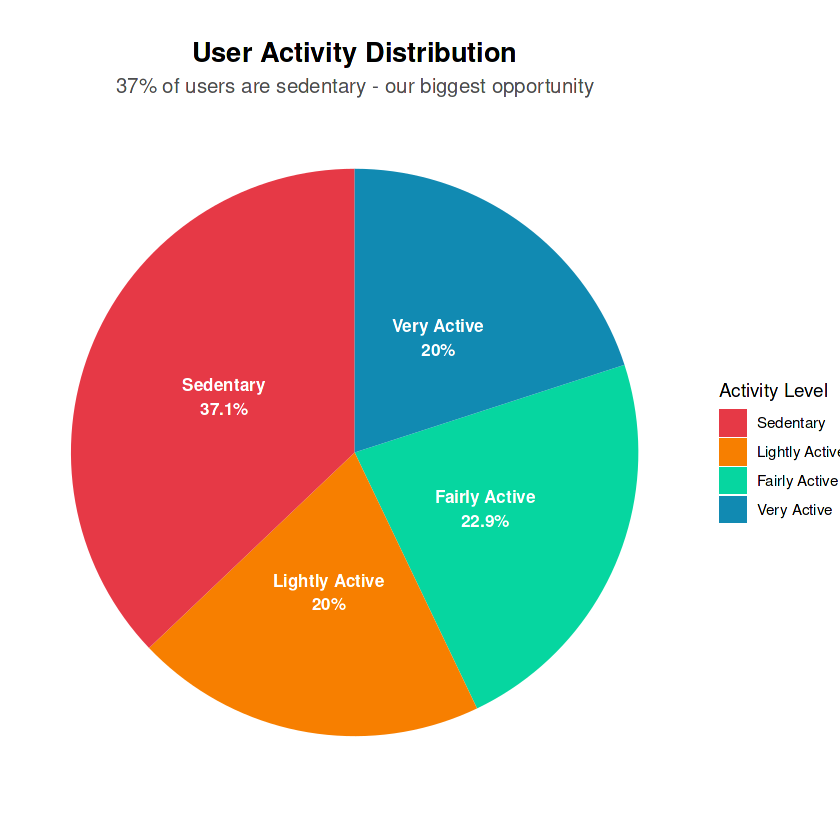

In [17]:
# Users in each activity category
activity_dist <- user_activity_classification %>%
  count(activity_category) %>%
  mutate(
    percentage = round((n / sum(n)) * 100, 1),
    # Put categories in order from least to most active
    activity_category = factor(activity_category, 
                               levels = c("Sedentary", "Lightly Active", "Fairly Active", "Very Active"))
  )

# Make a pie chart
viz1 <- ggplot(activity_dist, aes(x = "", y = percentage, fill = activity_category)) +
  geom_bar(stat = "identity", width = 1) +
  coord_polar("y", start = 0) +
  geom_text(aes(label = paste0(activity_category, "\n", percentage, "%")), 
            position = position_stack(vjust = 0.5), size = 3.5, color = "white", fontface = "bold") +
  # Choose colors for each slice
  scale_fill_manual(values = c("Sedentary" = "#E63946", 
                                "Lightly Active" = "#F77F00", 
                                "Fairly Active" = "#06D6A0", 
                                "Very Active" = "#118AB2")) +
  # Titles
  labs(
    title = "User Activity Distribution",
    subtitle = "37% of users are sedentary - our biggest opportunity",
    fill = "Activity Level"
  ) +
  theme_void() +
  theme(
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    plot.subtitle = element_text(size = 12, color = "gray30", hjust = 0.5),
    legend.position = "right"
  )

print(viz1)

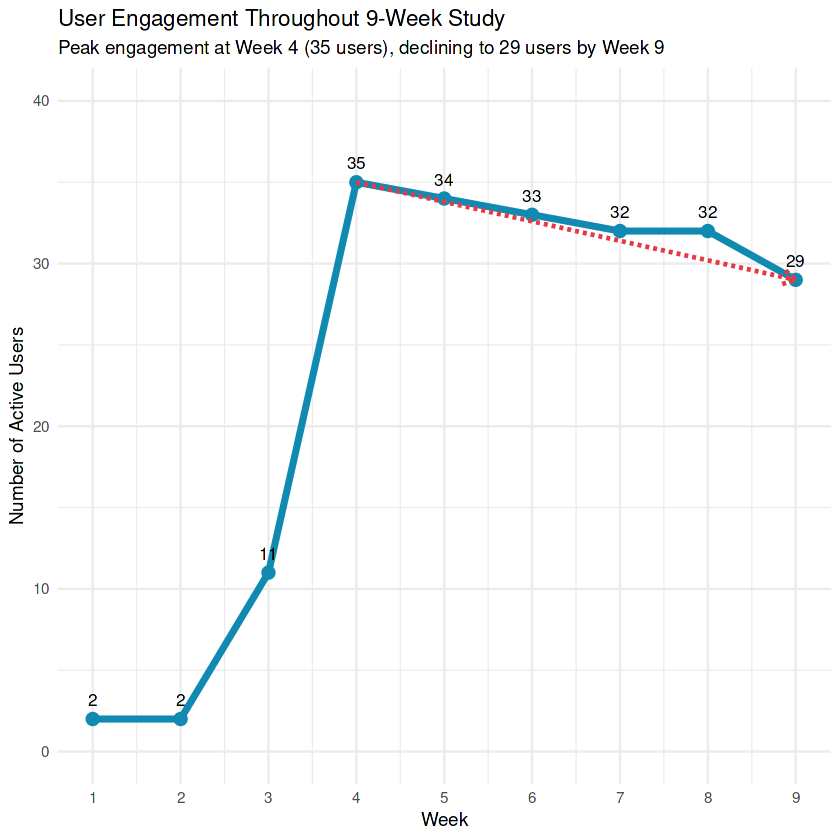

In [18]:
# Engagement and retention

# Calculate how many users were active each week, renumbered to study weeks
weekly_trend <- daily_activity %>%
  mutate(week = week(activity_date)) %>%
  group_by(week) %>%
  summarise(
    users_active = n_distinct(id),
    avg_steps = round(mean(total_steps), 0)
  ) %>%
  arrange(week) %>%
  mutate(
    study_week = row_number()  # Renumber as Week 1, 2, 3, etc.
  )

# Make a line chart showing all weeks 1-9
viz2 <- ggplot(weekly_trend, aes(x = study_week, y = users_active)) +
  geom_line(color = "#118AB2", linewidth = 1.5) +
  geom_point(color = "#118AB2", size = 3) +
  geom_text(aes(label = users_active), vjust = -1, size = 3.5) +
  # Add a line from Week 4 (peak) to Week 9 (drop-off)
  annotate("segment", x = 4, y = 35, xend = 9, yend = 29, 
           color = "#E63946", linewidth = 1, linetype = "dashed", 
           arrow = arrow(length = unit(0.3, "cm"))) +
  labs(
    title = "User Engagement Throughout 9-Week Study",
    subtitle = "Peak engagement at Week 4 (35 users), declining to 29 users by Week 9",
    x = "Week",
    y = "Number of Active Users"
  ) +
  theme_minimal() +
  scale_x_continuous(breaks = seq(1, 9, 1)) +
  ylim(0, 40)

print(viz2)

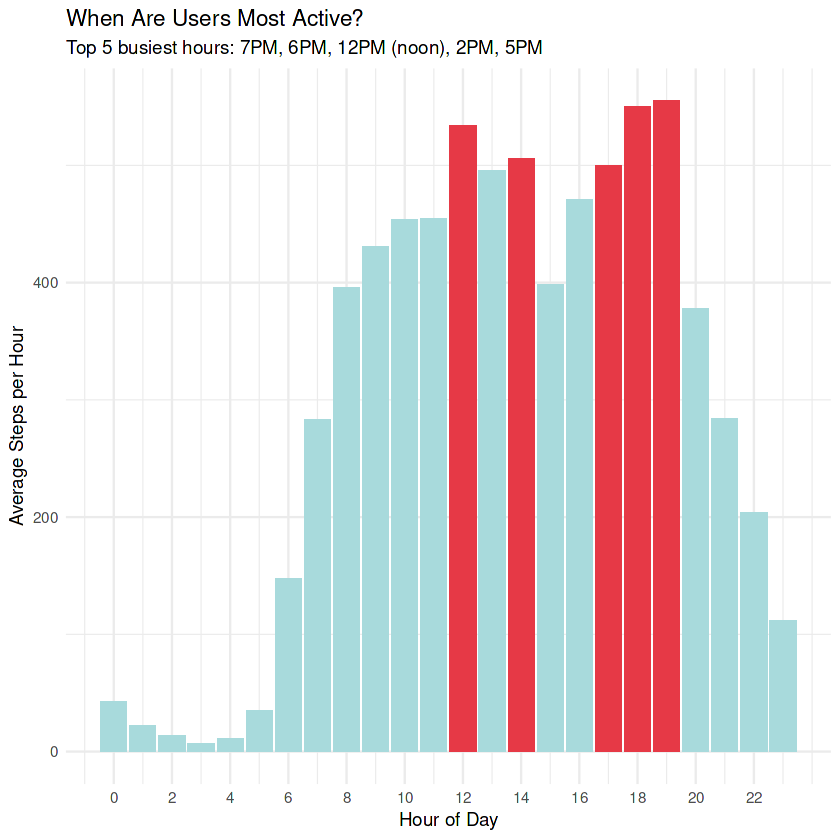

In [19]:
# Hours users are most active

# Calculate average steps for each hour of the day
hourly_pattern <- hourly_steps %>%
  mutate(hour = hour(activity_hour)) %>%
  group_by(hour) %>%
  summarise(avg_steps = round(mean(step_total), 0)) %>%
  arrange(desc(avg_steps)) %>%
  mutate(
    # Mark top 5 busiest hours
    rank = row_number(),
    is_peak = rank <= 5
  ) %>%
  arrange(hour) 
# Make a bar chart
viz3 <- ggplot(hourly_pattern, aes(x = hour, y = avg_steps, fill = is_peak)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("FALSE" = "#A8DADC", "TRUE" = "#E63946")) +
  labs(
    title = "When Are Users Most Active?",
    subtitle = "Top 5 busiest hours: 7PM, 6PM, 12PM (noon), 2PM, 5PM",
    x = "Hour of Day",
    y = "Average Steps per Hour"
  ) +
  theme_minimal() +
  theme(legend.position = "none") +
  scale_x_continuous(breaks = seq(0, 23, 2))

print(viz3)

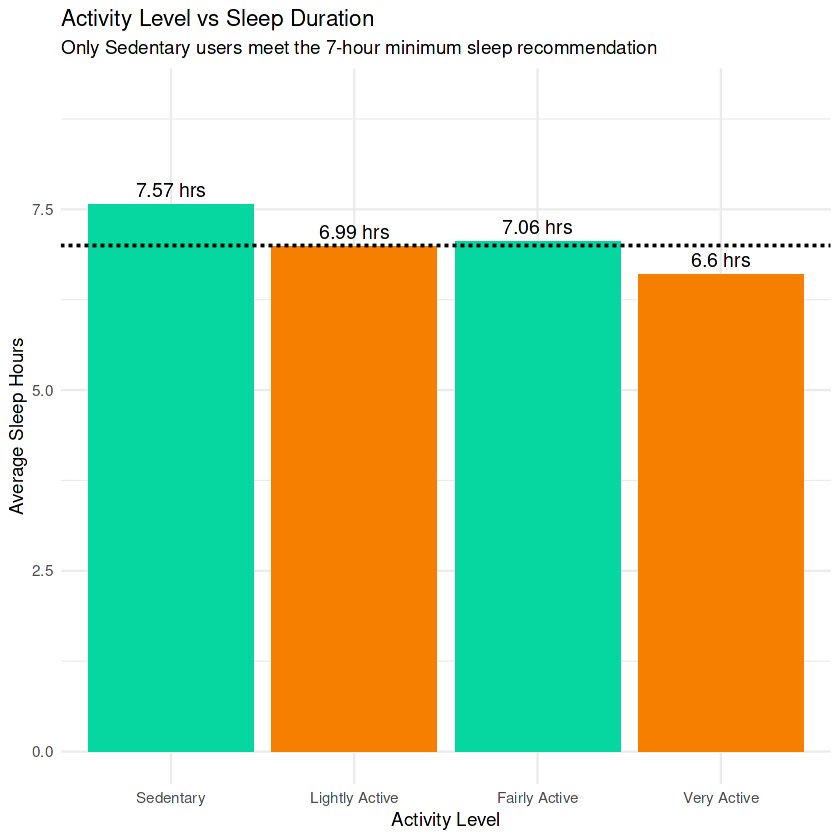

In [20]:
# Are users sleeping enough per CDC guidelines?

# Calculate average sleep for each activity level
sleep_by_activity <- activity_sleep %>%
  group_by(activity_level) %>%
  summarise(
    avg_sleep_hours = round(mean(sleep_hours), 2),
    count = n()
  ) %>%
  mutate(
    activity_level = factor(activity_level, 
                           levels = c("Sedentary", "Lightly Active", "Fairly Active", "Very Active")),
    # Check if they meet the 7-hour recommendation
    meets_recommendation = avg_sleep_hours >= 7
  )

# Make a bar chart
viz4 <- ggplot(sleep_by_activity, aes(x = activity_level, y = avg_sleep_hours, fill = meets_recommendation)) +
  geom_bar(stat = "identity") +
  # Add a line showing recommended 7 hours
  geom_hline(yintercept = 7, linetype = "dashed", color = "black", linewidth = 0.8) +
  geom_text(aes(label = paste0(avg_sleep_hours, " hrs")), vjust = -0.5, size = 4) +
  scale_fill_manual(values = c("TRUE" = "#06D6A0", "FALSE" = "#F77F00")) +
  labs(
    title = "Activity Level vs Sleep Duration",
    subtitle = "Only Sedentary users meet the 7-hour minimum sleep recommendation",
    x = "Activity Level",
    y = "Average Sleep Hours"
  ) +
  theme_minimal() +
  theme(legend.position = "none") +
  ylim(0, 9)

print(viz4)

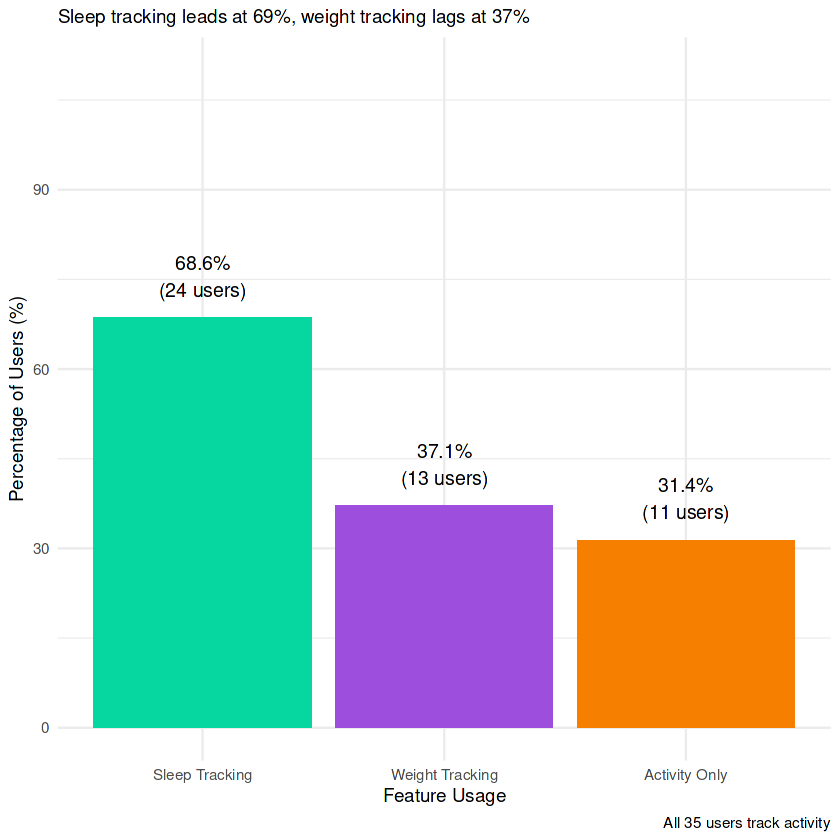

In [21]:
# Which features are being used the most?

# Create a table showing all usage
feature_adoption <- data.frame(
  feature = c("Sleep Tracking", "Weight Tracking", "Activity Only"),
  users = c(24, 13, 11),
  percentage = c(68.6, 37.1, 31.4)
) %>%
  mutate(
    feature = factor(feature, levels = c("Sleep Tracking", "Weight Tracking", "Activity Only"))
  )

# Make a bar chart
viz5 <- ggplot(feature_adoption, aes(x = feature, y = percentage, fill = feature)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = paste0(percentage, "%\n(", users, " users)")), 
            vjust = -0.5, size = 4) +
  scale_fill_manual(values = c("Sleep Tracking" = "#06D6A0", 
                                "Weight Tracking" = "#9D4EDD",
                                "Activity Only" = "#F77F00")) +
  labs(
    subtitle = "Sleep tracking leads at 69%, weight tracking lags at 37%",
    x = "Feature Usage",
    y = "Percentage of Users (%)",
    caption = "All 35 users track activity"
  ) +
  theme_minimal() +
  theme(legend.position = "none") +
  ylim(0, 110)

print(viz5)

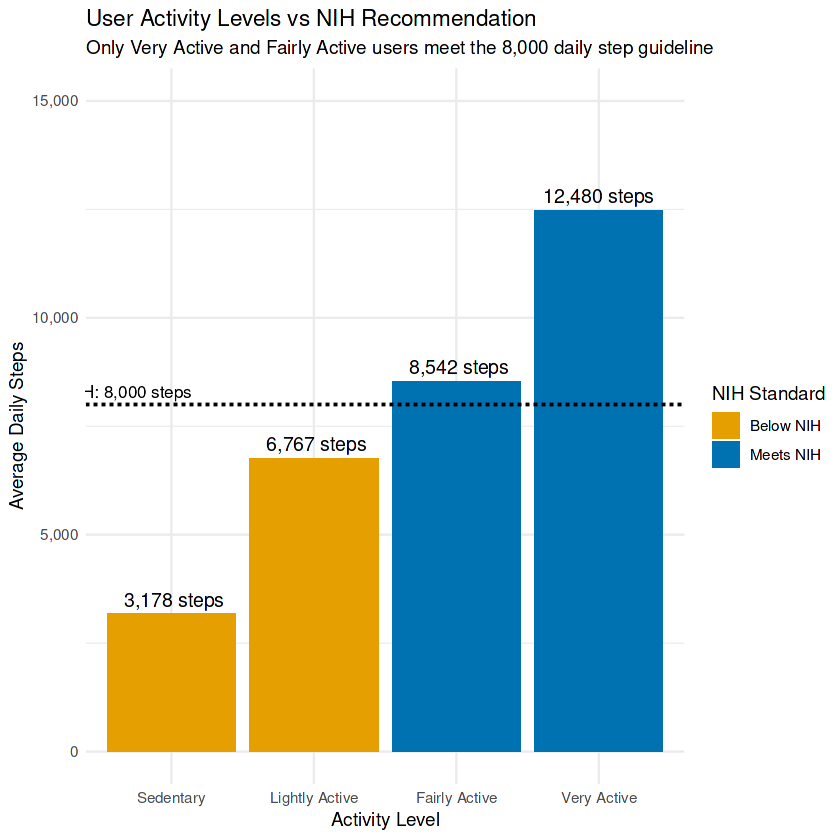

In [22]:
# Do activity levels meet NIH requirement?

# Find average and mean of steps for all activity categories
all_activity_steps <- user_activity_classification %>%
  group_by(activity_category) %>%
  summarise(
    avg_steps = round(mean(avg_daily_steps), 0),
    users = n()
  ) %>%
  mutate(
    activity_category = factor(activity_category, 
                               levels = c("Sedentary", "Lightly Active", "Fairly Active", "Very Active")),
    meets_nih = avg_steps >= 8000
  )

# Create bar chart
viz6 <- ggplot(all_activity_steps, aes(x = activity_category, y = avg_steps, fill = meets_nih)) +
  geom_bar(stat = "identity") +
  geom_hline(yintercept = 8000, linetype = "dashed", color = "black", linewidth = 0.8) +
  annotate("text", x = 0.7, y = 8000, label = "NIH: 8,000 steps", size = 3.5, vjust = -0.5) +
  geom_text(aes(label = paste0(format(avg_steps, big.mark = ","), " steps")), 
            vjust = -0.5, size = 4) +
  scale_fill_manual(values = c("FALSE" = "#E69F00", "TRUE" = "#0072B2"),
                    labels = c("Below NIH", "Meets NIH")) +
  labs(
    title = "User Activity Levels vs NIH Recommendation",
    subtitle = "Only Very Active and Fairly Active users meet the 8,000 daily step guideline",
    x = "Activity Level",
    y = "Average Daily Steps",
    fill = "NIH Standard"
  ) +
  theme_minimal() +
  theme(legend.position = "right") +
  scale_y_continuous(labels = scales::comma, limits = c(0, 15000))

print(viz6)

# Act

Based on the analysis, FitBit's smart device users show strong initial engagement (87% wear rate) but face two critical challenges: a 17% user drop-off between weeks 4 and 5, and 31% of users engaging with only basic activity tracking instead of utilizing multiple features. The data reveals that most users are not fitness enthusiasts but rather individuals struggling to maintain consistent activity levels, with 37% classified as sedentary. The inverse relationship between activity and sleep — very active users sleeping less — presents a unique opportunity for Bellabeat to differentiate itself from competitors by promoting a holistic wellness lifestyle rather than fitness performance.

In addition to this dataset, Bellabeat can also improve its products by comparing against competitors that promote a holistic lifestyle, such as Oura and Whoop. Understanding user demographics — specifically whether sedentary users are busy professionals, parents, or students — would inform which motivational strategies resonate best.

Exit interviews with the 6 users who dropped off and surveys from the 13 super-users with perfect wear would reveal the "why" behind engagement patterns. Extending the study from 9 weeks to 6–12 months would also show whether users who survive the week 4–5 drop-off maintain long-term engagement or face additional churn points. This would validate whether the critical retention window truly falls at weeks 4–5 or whether other patterns emerge.

**How the team can apply these insights to Leaf**

**Product team**

* Create a "30-Day Wellness Journey" achievement that unlocks at day 30.
* Redesign the onboarding experience to introduce sleep and stress tracking within the first week, not as separate features but as connected parts of a wellness journey.
* Personalized progress summaries with data easy to read and that motivates towards a new goal.
* Push notifications to nudge engagement.
  
**Marketing team**
* Launch in-app challenges that connect users with local communities or friends to build accountability.
* Shift messaging from fitness-focused to wellness-focused, positioning Leaf as "balance, not burnout" to resonate with the sedentary majority.
* Target the inverse activity-sleep finding directly with recovery-focused marketing.
* Use testimonials from the 13 super-users with perfect wear rates.

**Customer success team**
* Implement proactive email outreach at days 25-30 to users showing disengagement signs, highlighting their accomplishments and what consistency can achieve.
* Send sedentary users motivational content focused on small wins and habit-building, not intimidating fitness goals.
* Send very active users sleeping less than 7 hours recovery-focused tips and rest day encouragement.
* Educate all users on Leaf's sleep tracking capabilities and the proven connection between activity and sleep quality.

**Next steps for Bellabeat**

**Immediate action** 
* Implement the 30-Day Wellness Journey achievement feature to address the critical Week 4-5 drop-off period.

**Short-term**  
* Redesign onboarding to introduce sleep tracking in the first week.
  
* Develop beginner-friendly features for sedentary users with customizable goals starting at 3k-5k steps instead of 10,000.

* Create recovery content for very active users averaging <7 hours hours of sleep.

* Test push notifications timed for non-peak activity hours.


**Long-term**
* Research super-users with perfect wear to identify success drivers.
* Evaluate whether to improve weight tracking or pivot to stress and meditation features that better align with Bellabeat's wellness positioning.
* Develop community features to help users build sustainable habits.